# PyTorch Custom Model Training for Affect Recognition Dataset
This notebook trains Custom Model for multi-task learning: expression classification and valence-arousal regression

In [1]:
import os
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
from dataclasses import dataclass
from typing import Dict, List, Optional, Tuple
import random

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
import torchvision.transforms as T

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

# Set random seeds for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

PyTorch version: 2.6.0+cu124
CUDA available: True
GPU: Tesla T4
Using device: cuda


In [2]:
class Config:
    # Dataset paths - MODIFY THESE PATHS ACCORDING TO YOUR SETUP
    DATASET_ROOT = "/kaggle/input/arousal-valence-dataset/Dataset/Dataset/"  # Change this to your dataset path
    IMAGES_DIR = os.path.join(DATASET_ROOT, "images")
    ANNOTATIONS_DIR = os.path.join(DATASET_ROOT, "annotations")
    
    # Model parameters
    IMAGE_SIZE = 224
    BATCH_SIZE = 32
    EPOCHS = 100
    LEARNING_RATE = 1e-3
    WEIGHT_DECAY = 1e-4
    
    # Split ratios
    SPLIT_RATIOS = {"train": 0.8, "val": 0.1, "test": 0.1}
    
    # Expression labels
    EXPRESSION_LABELS = {
        0: "Neutral", 1: "Happy", 2: "Sad", 3: "Surprise", 
        4: "Fear", 5: "Disgust", 6: "Anger", 7: "Contempt"
    }
    
    NUM_CLASSES = 8

config = Config()

In [3]:
@dataclass
class SampleIndex:
    sample_id: str
    image_path: str
    exp_path: str
    val_path: str
    aro_path: str

def _id_to_paths(sample_id: str) -> SampleIndex:
    """Build file paths for a given sample id."""
    img_path = os.path.join(config.IMAGES_DIR, f"{sample_id}.jpg")
    exp_path = os.path.join(config.ANNOTATIONS_DIR, f"{sample_id}_exp.npy")
    val_path = os.path.join(config.ANNOTATIONS_DIR, f"{sample_id}_val.npy")
    aro_path = os.path.join(config.ANNOTATIONS_DIR, f"{sample_id}_aro.npy")
    return SampleIndex(sample_id, img_path, exp_path, val_path, aro_path)

def build_index() -> List[SampleIndex]:
    """Scan dataset folders and build a valid sample index."""
    ids = []
    for name in os.listdir(config.IMAGES_DIR):
        if not name.lower().endswith(".jpg"):
            continue
        sample_id = os.path.splitext(name)[0]
        idx = _id_to_paths(sample_id)
        if (os.path.exists(idx.exp_path) and 
            os.path.exists(idx.val_path) and 
            os.path.exists(idx.aro_path)):
            ids.append(sample_id)
    
    ids.sort(key=lambda x: int(x) if x.isdigit() else x)
    return [_id_to_paths(i) for i in ids]

In [4]:
class AffectDataset(Dataset):
    def __init__(self, indices: List[SampleIndex], transform=None):
        self.indices = indices
        self.transform = transform

    def __len__(self) -> int:
        return len(self.indices)

    def __getitem__(self, idx: int):
        entry = self.indices[idx]

        # Load image
        img = Image.open(entry.image_path).convert("RGB")
        if self.transform is not None:
            img = self.transform(img)

        # Load annotations
        exp = np.load(entry.exp_path).astype(np.int64)
        if exp.ndim:
            exp = int(exp.reshape(-1)[0])
        else:
            exp = int(exp)  # Ensure it's an integer
            
        val = float(np.load(entry.val_path).reshape(-1)[0])
        aro = float(np.load(entry.aro_path).reshape(-1)[0])

        exp = torch.tensor(exp, dtype=torch.long)
        target_reg = torch.tensor([val, aro], dtype=torch.float32)

        return {
            "image": img,
            "exp": exp,
            "reg": target_reg,
            "id": entry.sample_id,
        }

In [5]:
def get_train_transforms():
    """Enhanced data augmentation for SimpleCNN training."""
    return transforms.Compose([
        transforms.Resize((config.IMAGE_SIZE, config.IMAGE_SIZE)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
        transforms.RandomRotation(degrees=15),
        transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
        transforms.RandomPerspective(distortion_scale=0.2, p=0.3),
        transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        transforms.RandomErasing(p=0.2, scale=(0.02, 0.33), ratio=(0.3, 3.3)),
    ])

def get_eval_transforms():
    """Data preprocessing for evaluation."""
    return transforms.Compose([
        transforms.Resize((config.IMAGE_SIZE, config.IMAGE_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])

In [16]:
class DualHead(nn.Module):
    def __init__(self, in_features: int, num_classes: int = config.NUM_CLASSES):
        super().__init__()
        self.cls = nn.Linear(in_features, num_classes)
        self.reg = nn.Linear(in_features, 2)

    def forward(self, x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        """Classification and regression heads."""
        logits = self.cls(x)
        reg = torch.tanh(self.reg(x))
        return logits, reg

class SEBlock(nn.Module):
    """Squeeze-and-Excitation Block for channel attention."""
    def __init__(self, channels: int, reduction: int = 16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, channels // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        b, c, _, _ = x.size()
        y = self.avg_pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1, 1)
        return x * y.expand_as(x)

class EnhancedDualHead(nn.Module):
    """Enhanced dual head with better feature processing."""
    def __init__(self, in_features: int, num_classes: int = config.NUM_CLASSES):
        super().__init__()
        hidden_dim = 1024
        
        # Shared feature processing
        self.shared = nn.Sequential(
            nn.Linear(in_features, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4)  
        )
        
        # Classification head
        self.cls = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.BatchNorm1d(hidden_dim // 2),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim // 2, num_classes)
        )
        
        # Regression head
        self.reg = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.BatchNorm1d(hidden_dim // 2),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim // 2, 2)
        )
    
    def forward(self, x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        shared_features = self.shared(x)
        logits = self.cls(shared_features)
        reg = torch.tanh(self.reg(shared_features))
        return logits, reg

class SimpleCNN(nn.Module):
    """A simple custom CNN with SE + dual pooling + dual head."""
    def __init__(self, num_classes: int = config.NUM_CLASSES):
        super().__init__()

        # Feature extractor
        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1),  # 32xHxW
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  # downsample

            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),  # 64xH/2xW/2
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),  # 128xH/4xW/4
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )

        # Add one SE block for attention
        self.se_block = SEBlock(128)

        # Dual pooling
        self.pool_avg = nn.AdaptiveAvgPool2d((1, 1))
        self.pool_max = nn.AdaptiveMaxPool2d((1, 1))

        # Feature enhancement
        feature_dim = 128 * 2  # because avg+max
        self.feature_enhance = nn.Sequential(
            nn.Linear(feature_dim, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3)
        )

        # Dual head (classification + regression)
        self.head = EnhancedDualHead(256)

    def forward(self, x):
        x = self.conv_layers(x)
        x = self.se_block(x)

        avg_pool = self.pool_avg(x)
        max_pool = self.pool_max(x)

        x = torch.cat([avg_pool, max_pool], dim=1)
        x = torch.flatten(x, 1)

        x = self.feature_enhance(x)
        return self.head(x)



def build_model(name, pretrained: bool = True) -> nn.Module:
    """Build Mobile  Net model by name."""
    name = name.lower()
    if name == "simplecnn":
        return SimpleCNN()
    else:
        raise ValueError(f"Unknown model: {name}")

In [7]:
class EnhancedMultiTaskLoss(nn.Module):
    def __init__(self, cls_weight=2.0, reg_weight=0.5, class_weights=None, 
                 focal_alpha=0.25, focal_gamma=2.0, use_focal=True):
        super().__init__()
        self.cls_weight = cls_weight
        self.reg_weight = reg_weight
        self.use_focal = use_focal
        
        # Standard classification loss
        if class_weights is not None:
            class_weights = torch.FloatTensor(class_weights).to(device)
        self.cls_criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)
        
        # Focal loss parameters
        self.focal_alpha = focal_alpha
        self.focal_gamma = focal_gamma
        
        # Regression losses
        self.reg_criterion = nn.SmoothL1Loss()  # Huber loss - more robust than MSE
    
    def focal_loss(self, inputs, targets):
        """Focal loss for handling hard examples."""
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = self.focal_alpha * (1 - pt) ** self.focal_gamma * ce_loss
        return focal_loss.mean()
    
    def forward(self, cls_pred, reg_pred, cls_target, reg_target):
        if self.use_focal:
            cls_loss = self.focal_loss(cls_pred, cls_target)
        else:
            cls_loss = self.cls_criterion(cls_pred, cls_target)
        
        reg_loss = self.reg_criterion(reg_pred, reg_target)
        
        total_loss = self.cls_weight * cls_loss + self.reg_weight * reg_loss
        
        return {
            'total_loss': total_loss,
            'cls_loss': cls_loss,
            'reg_loss': reg_loss
        }

In [8]:
class AverageMeter:
    def __init__(self):
        self.reset()
    
    def reset(self):
        self.val = 0
        self.avg = 0
        self.sum = 0
        self.count = 0
    
    def update(self, val, n=1):
        self.val = val
        self.sum += val * n
        self.count += n
        self.avg = self.sum / self.count

def accuracy(output, target):
    """Calculate classification accuracy."""
    pred = output.argmax(dim=1)
    correct = pred.eq(target).float()
    return correct.mean().item()

def train_epoch(model, dataloader, criterion, optimizer, scheduler, epoch):
    model.train()

    losses = AverageMeter()
    cls_losses = AverageMeter()
    reg_losses = AverageMeter()
    accuracies = AverageMeter()

    for i, batch in enumerate(dataloader):
        images = batch['image'].to(device)
        exp_targets = batch['exp'].to(device)
        reg_targets = batch['reg'].to(device)

        # Forward pass
        cls_pred, reg_pred = model(images)

        # Calculate losses
        loss_dict = criterion(cls_pred, reg_pred, exp_targets, reg_targets)

        # Backward pass
        optimizer.zero_grad()
        loss_dict['total_loss'].backward()

        # Gradient clipping for stability
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        # IMPORTANT: step scheduler each batch when using OneCycleLR
        if scheduler is not None:
            scheduler.step()

        # Update metrics
        batch_size = images.size(0)
        losses.update(loss_dict['total_loss'].item(), batch_size)
        cls_losses.update(loss_dict['cls_loss'].item(), batch_size)
        reg_losses.update(loss_dict['reg_loss'].item(), batch_size)
        accuracies.update(accuracy(cls_pred, exp_targets), batch_size)

        if i % 50 == 0:
            print(f'Epoch [{epoch}][{i}/{len(dataloader)}] '
                  f'Loss: {losses.val:.4f} ({losses.avg:.4f}) '
                  f'Acc: {accuracies.val:.4f} ({accuracies.avg:.4f}) '
                  f'LR: {optimizer.param_groups[0]["lr"]:.6f}')

    return {
        'loss': losses.avg,
        'cls_loss': cls_losses.avg,
        'reg_loss': reg_losses.avg,
        'accuracy': accuracies.avg
    }


def validate_epoch(model, dataloader, criterion):
    model.eval()
    
    losses = AverageMeter()
    cls_losses = AverageMeter()
    reg_losses = AverageMeter()
    accuracies = AverageMeter()
    
    all_preds = []
    all_targets = []
    all_reg_preds = []
    all_reg_targets = []
    
    with torch.no_grad():
        for batch in dataloader:
            images = batch['image'].to(device)
            exp_targets = batch['exp'].to(device)
            reg_targets = batch['reg'].to(device)
            
            # Forward pass
            cls_pred, reg_pred = model(images)
            
            # Calculate losses
            loss_dict = criterion(cls_pred, reg_pred, exp_targets, reg_targets)
            
            # Update metrics
            batch_size = images.size(0)
            losses.update(loss_dict['total_loss'].item(), batch_size)
            cls_losses.update(loss_dict['cls_loss'].item(), batch_size)
            reg_losses.update(loss_dict['reg_loss'].item(), batch_size)
            accuracies.update(accuracy(cls_pred, exp_targets), batch_size)
            
            # Store predictions for detailed analysis
            all_preds.extend(cls_pred.argmax(dim=1).cpu().numpy())
            all_targets.extend(exp_targets.cpu().numpy())
            all_reg_preds.extend(reg_pred.cpu().numpy())
            all_reg_targets.extend(reg_targets.cpu().numpy())
    
    return {
        'loss': losses.avg,
        'cls_loss': cls_losses.avg,
        'reg_loss': reg_losses.avg,
        'accuracy': accuracies.avg,
        'predictions': all_preds,
        'targets': all_targets,
        'reg_predictions': all_reg_preds,
        'reg_targets': all_reg_targets
    }

In [9]:
print("Building dataset index...")
try:
    all_indices = build_index()
    print(f"Found {len(all_indices)} valid samples")
    
    if len(all_indices) == 0:
        print("ERROR: No valid samples found!")
        print("Please check your dataset paths in the Config class")
        raise Exception("No valid samples found - check your dataset paths!")

except Exception as e:
    print(f"Error building index: {e}")
    raise

# Load all labels for stratified splitting
print("Loading labels for stratification...")
all_labels = []
for idx in all_indices:
    exp = np.load(idx.exp_path).astype(np.int64)
    if exp.ndim:
        exp = int(exp.reshape(-1)[0])
    else:
        exp = int(exp)  # Ensure it's an integer
    all_labels.append(exp)

print(f"Loaded {len(all_labels)} labels")
print(f"Label range: {min(all_labels)} to {max(all_labels)}")
print(f"Unique labels: {sorted(set(all_labels))}")

# Check for label distribution
label_counts = np.bincount(all_labels, minlength=config.NUM_CLASSES)
print(f"Label distribution: {label_counts}")

# Use sklearn's train_test_split for proper stratification
# First split: train vs (val+test) - 80% vs 20%
train_idx, temp_idx = train_test_split(
    range(len(all_indices)), 
    test_size=0.2, 
    stratify=all_labels, 
    random_state=SEED
)

# Split the remaining 20% into val and test (10% each)
val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.5,
    stratify=[all_labels[i] for i in temp_idx],
    random_state=SEED
)

print(f"\nTrain samples: {len(train_idx)}")
print(f"Validation samples: {len(val_idx)}")
print(f"Test samples: {len(test_idx)}")

# Verify the splits are balanced
train_labels_check = [all_labels[i] for i in train_idx]
val_labels_check = [all_labels[i] for i in val_idx]
test_labels_check = [all_labels[i] for i in test_idx]

print("Verification - actual class counts:")
print(f"Train: {np.bincount(train_labels_check, minlength=8)}")
print(f"Val: {np.bincount(val_labels_check, minlength=8)}")
print(f"Test: {np.bincount(test_labels_check, minlength=8)}")

# Calculate class weights for handling any imbalance
classes = np.arange(config.NUM_CLASSES)
class_weights_array = compute_class_weight('balanced', classes=classes, y=all_labels)
class_weights_dict = {i: weight for i, weight in enumerate(class_weights_array)}
print(f"\nCalculated class weights: {class_weights_dict}")

# Create datasets and dataloaders
train_indices = [all_indices[i] for i in train_idx]
val_indices = [all_indices[i] for i in val_idx]
test_indices = [all_indices[i] for i in test_idx]

train_dataset = AffectDataset(train_indices, transform=get_train_transforms())
val_dataset = AffectDataset(val_indices, transform=get_eval_transforms())
test_dataset = AffectDataset(test_indices, transform=get_eval_transforms())

train_loader = DataLoader(train_dataset, batch_size=config.BATCH_SIZE, shuffle=True, 
                         num_workers=4, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=config.BATCH_SIZE, shuffle=False, 
                       num_workers=4, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=config.BATCH_SIZE, shuffle=False, 
                        num_workers=4, pin_memory=True)

print("Datasets and dataloaders created successfully!")

Building dataset index...
Found 3999 valid samples
Loading labels for stratification...
Loaded 3999 labels
Label range: 0 to 7
Unique labels: [0, 1, 2, 3, 4, 5, 6, 7]
Label distribution: [500 500 500 500 500 500 500 499]

Train samples: 3199
Validation samples: 400
Test samples: 400
Verification - actual class counts:
Train: [400 400 400 400 400 400 400 399]
Val: [50 50 50 50 50 50 50 50]
Test: [50 50 50 50 50 50 50 50]

Calculated class weights: {0: 0.99975, 1: 0.99975, 2: 0.99975, 3: 0.99975, 4: 0.99975, 5: 0.99975, 6: 0.99975, 7: 1.001753507014028}
Datasets and dataloaders created successfully!


In [17]:
# Build model -
print("Building SimpleCNN model...")
model_name = "SimpleCNN"
model = build_model(model_name)
model = model.to(device)

# Print model summary
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Model: {model_name}")
print(f"Model has {count_parameters(model):,} trainable parameters")

# Setup enhanced loss function
criterion = EnhancedMultiTaskLoss(
    cls_weight=2.5,  # Higher weight for classification
    reg_weight=0.4,  # Lower weight for regression
    class_weights=class_weights_array,
    use_focal=True  # Use focal loss for hard examples
)

# Setup optimizer with different learning rates for backbone and head
backbone_params = []
head_params = []

for name, param in model.named_parameters():
    if 'head' in name:
        head_params.append(param)
    else:
        backbone_params.append(param)

optimizer = optim.AdamW([
    {'params': backbone_params, 'lr': config.LEARNING_RATE * 0.1},  # Lower LR for pretrained backbone
    {'params': head_params, 'lr': config.LEARNING_RATE}  # Higher LR for new head
], weight_decay=config.WEIGHT_DECAY)

# Setup advanced scheduler
scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=[config.LEARNING_RATE * 0.1, config.LEARNING_RATE],
    epochs=config.EPOCHS,
    steps_per_epoch=len(train_loader),
    pct_start=0.3,
    anneal_strategy='cos'
)

print("Model, loss, optimizer, and scheduler configured!")

Building SimpleCNN model...
Model: SimpleCNN
Model has 1,483,530 trainable parameters
Model, loss, optimizer, and scheduler configured!


In [18]:
print("Starting training...")

train_history = {
    'train_loss': [],
    'train_accuracy': [],
    'val_loss': [],
    'val_accuracy': [],
    'lr': []
}

best_val_acc = 0.0
patience_counter = 0
patience = 25
best_model_state = None

for epoch in range(config.EPOCHS):
    print(f'\nEpoch {epoch + 1}/{config.EPOCHS}')
    print('-' * 60)
    
    # Training phase
    train_metrics = train_epoch(model, train_loader, criterion, optimizer, scheduler, epoch + 1)
    
    # Validation phase
    val_metrics = validate_epoch(model, val_loader, criterion)
    
    # Update history
    train_history['train_loss'].append(train_metrics['loss'])
    train_history['train_accuracy'].append(train_metrics['accuracy'])
    train_history['val_loss'].append(val_metrics['loss'])
    train_history['val_accuracy'].append(val_metrics['accuracy'])
    train_history['lr'].append(optimizer.param_groups[0]['lr'])
    
    print(f'Train Loss: {train_metrics["loss"]:.4f}, Train Acc: {train_metrics["accuracy"]:.4f}')
    print(f'Val Loss: {val_metrics["loss"]:.4f}, Val Acc: {val_metrics["accuracy"]:.4f}')
    
    # Save best model
    if val_metrics['accuracy'] > best_val_acc:
        best_val_acc = val_metrics['accuracy']
        best_model_state = model.state_dict().copy()
        torch.save(best_model_state, f'best_{model_name}_affect.pth')
        print(f'New best validation accuracy: {best_val_acc:.4f}')
        patience_counter = 0
    else:
        patience_counter += 1
    
    # Early stopping
    if patience_counter >= patience:
        print(f'Early stopping triggered after {epoch + 1} epochs')
        break

print("Training completed!")
print(f"Best validation accuracy: {best_val_acc:.4f}")

Starting training...

Epoch 1/100
------------------------------------------------------------
Epoch [1][0/100] Loss: 1.1196 (1.1196) Acc: 0.0938 (0.0938) LR: 0.000004
Epoch [1][50/100] Loss: 1.2004 (1.1340) Acc: 0.1250 (0.1195) LR: 0.000004
Train Loss: 1.1299, Train Acc: 0.1138
Val Loss: 1.0351, Val Acc: 0.1325
New best validation accuracy: 0.1325

Epoch 2/100
------------------------------------------------------------
Epoch [2][0/100] Loss: 1.1291 (1.1291) Acc: 0.0938 (0.0938) LR: 0.000004
Epoch [2][50/100] Loss: 1.1408 (1.1056) Acc: 0.0625 (0.1256) LR: 0.000005
Train Loss: 1.1093, Train Acc: 0.1178
Val Loss: 1.0304, Val Acc: 0.1350
New best validation accuracy: 0.1350

Epoch 3/100
------------------------------------------------------------
Epoch [3][0/100] Loss: 1.1885 (1.1885) Acc: 0.0312 (0.0312) LR: 0.000005
Epoch [3][50/100] Loss: 1.1000 (1.1092) Acc: 0.1250 (0.1164) LR: 0.000006
Train Loss: 1.1064, Train Acc: 0.1247
Val Loss: 1.0338, Val Acc: 0.1225

Epoch 4/100
-------------

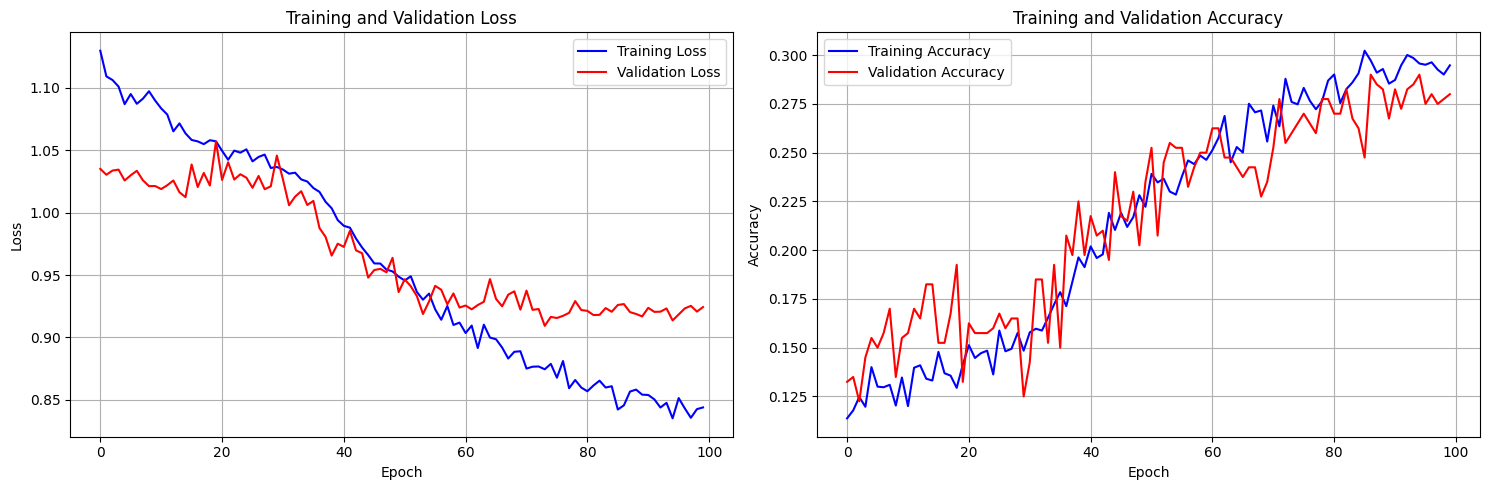

In [19]:
def plot_training_history(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    # Loss plot
    ax1.plot(history['train_loss'], label='Training Loss', color='blue')
    ax1.plot(history['val_loss'], label='Validation Loss', color='red')
    ax1.set_title('Training and Validation Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True)
    
    # Accuracy plot
    ax2.plot(history['train_accuracy'], label='Training Accuracy', color='blue')
    ax2.plot(history['val_accuracy'], label='Validation Accuracy', color='red')
    ax2.set_title('Training and Validation Accuracy')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.legend()
    ax2.grid(True)
    
    plt.tight_layout()
    plt.show()

plot_training_history(train_history)

Loading best model for evaluation...
Loaded best model from best_SimpleCNN_affect.pth
Evaluating on test set...

Test Results:
Test Loss: 0.8341
Test Accuracy: 0.3375

Classification Report:
              precision    recall  f1-score   support

     Neutral       0.16      0.14      0.15        50
       Happy       0.46      0.38      0.42        50
         Sad       0.29      0.44      0.35        50
    Surprise       0.36      0.32      0.34        50
        Fear       0.36      0.42      0.39        50
     Disgust       0.36      0.16      0.22        50
       Anger       0.36      0.32      0.34        50
    Contempt       0.37      0.52      0.43        50

    accuracy                           0.34       400
   macro avg       0.34      0.34      0.33       400
weighted avg       0.34      0.34      0.33       400



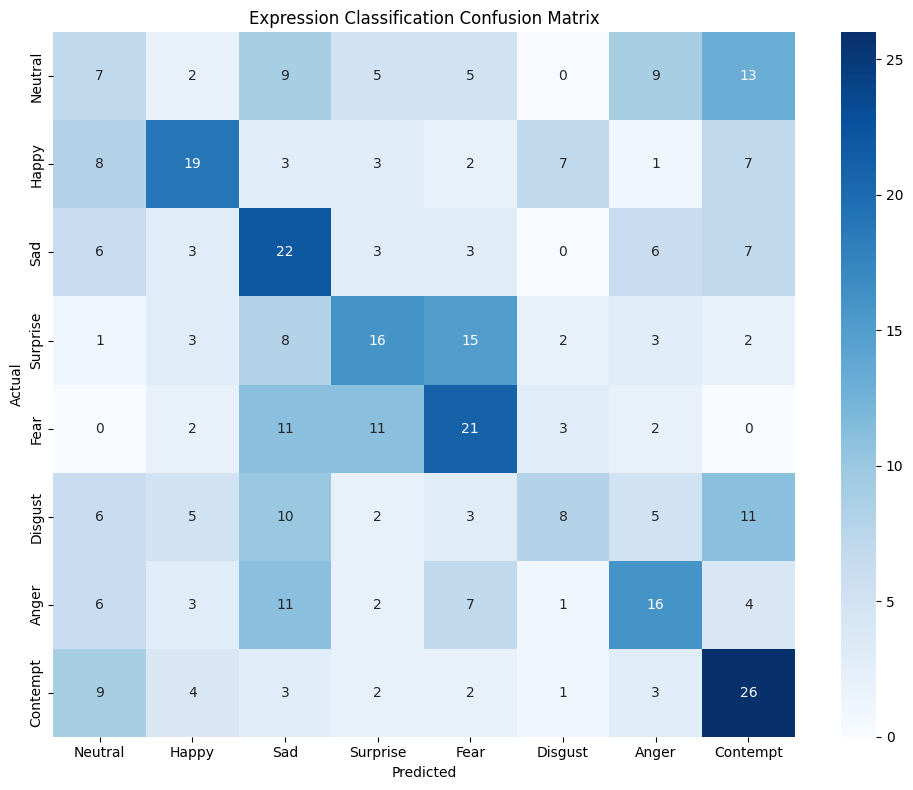

In [20]:
print("Loading best model for evaluation...")
best_file = f'best_{model_name}_affect.pth'
if os.path.exists(best_file):
    model.load_state_dict(torch.load(best_file, map_location=device))
    print(f"Loaded best model from {best_file}")
else:
    print(f"No best model file found at {best_file}, continuing with current model weights.")

print("Evaluating on test set...")
test_metrics = validate_epoch(model, test_loader, criterion)

print(f"\nTest Results:")
print(f"Test Loss: {test_metrics['loss']:.4f}")
print(f"Test Accuracy: {test_metrics['accuracy']:.4f}")

# Detailed classification report
print("\nClassification Report:")
print(classification_report(
    test_metrics['targets'],
    test_metrics['predictions'],
    target_names=[config.EXPRESSION_LABELS[i] for i in range(config.NUM_CLASSES)]
))

# Confusion matrix
plt.figure(figsize=(10, 8))
cm = confusion_matrix(test_metrics['targets'], test_metrics['predictions'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[config.EXPRESSION_LABELS[i] for i in range(config.NUM_CLASSES)],
            yticklabels=[config.EXPRESSION_LABELS[i] for i in range(config.NUM_CLASSES)])
plt.title('Expression Classification Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

In [21]:
# Save the final model
torch.save(model.state_dict(), 'simpleCNN_affect.pth')
print("Model saved")

Model saved
